In [4]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import poppy
import threading as th
import time 
from IPython.display import clear_output
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import multiprocessing

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3, imshow
from scoob_llowfsc import psds
from scoob_llowfsc import llowfsc
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()


952
0


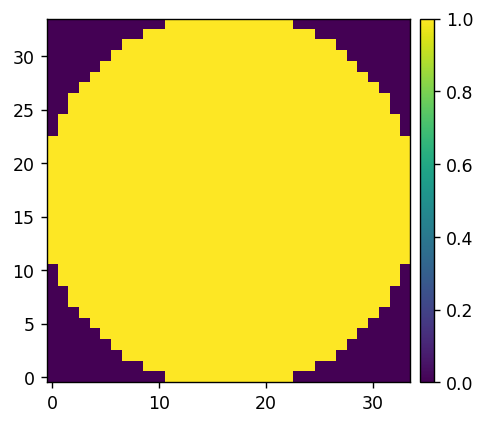

In [5]:
reload(scoobi)
wfe_channel = 'dm00disp01'
wfe_stream = ImageStream(wfe_channel)

Nact = 34
dm_mask = utils.create_circ_mask(Nact, Nact, radius=Nact//2+1/2)
print(dm_mask.sum())
imshow([dm_mask])

29.0888208681574 nm
0.0005


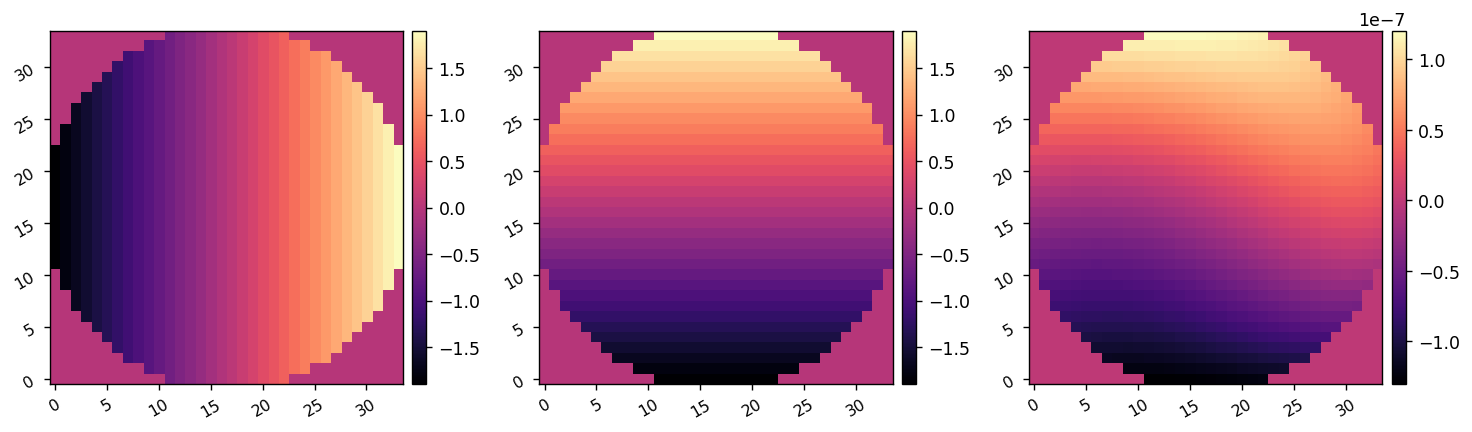

In [12]:
reload(psds)

total_pupil_diam = 2.4*u.m
dm_beam_diam = 9.1*u.mm
jitter = 10*u.mas 

fmax = 1000*u.Hz
tmax = 10*u.min
tmax = 3*u.hour
# tmax = 5*u.hour

mag = (total_pupil_diam / dm_beam_diam).decompose().value
tt_pv_to_rms = 1/4
tt_at_pupil_pv = np.tan(mag*jitter).value * dm_beam_diam
tt_at_pupil_rms = tt_at_pupil_pv * tt_pv_to_rms
print(tt_at_pupil_rms.to(u.nm))

wfe_modes_rms = np.array(2*[tt_at_pupil_rms.to_value(u.m)] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[20e-9] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[30e-9] + 3*[5e-9] + 5*[2.5e-9])
knee_freqs = np.array([0.05]*2 + [0.005]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(dm_mask, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = psds.generate_freqs(Nf=2**22+1, f_max=fmax)

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = psds.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = psds.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)

wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)]

times = times[times<tmax.to_value(u.s)]
interval = float(times[1] - times[0])
print(interval)

Nsamps = times.shape[0]
tip = wfe_time_series[0]
tilt = wfe_time_series[1]
defocus = wfe_time_series[2]

lo_wfe = xp.sum( wfe_time_series[:, 500, None, None] * wfe_modes, axis=0)
imshow3(wfe_modes[0], wfe_modes[1], lo_wfe)

wfe_data = {
    'times':times,
    'wfe_rms_time_series':wfe_time_series,
    'wfe_modes':wfe_modes,
    'modal_rms':wfe_modes_rms,
    'modal_knee_freqs':knee_freqs,
    'seeds':seeds,
    'fmax':fmax,
}
# utils.save_pickle(f'data/{today}_injected_wfe_data.pkl', wfe_data)


/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/psds.py:149: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(psd_xlims)


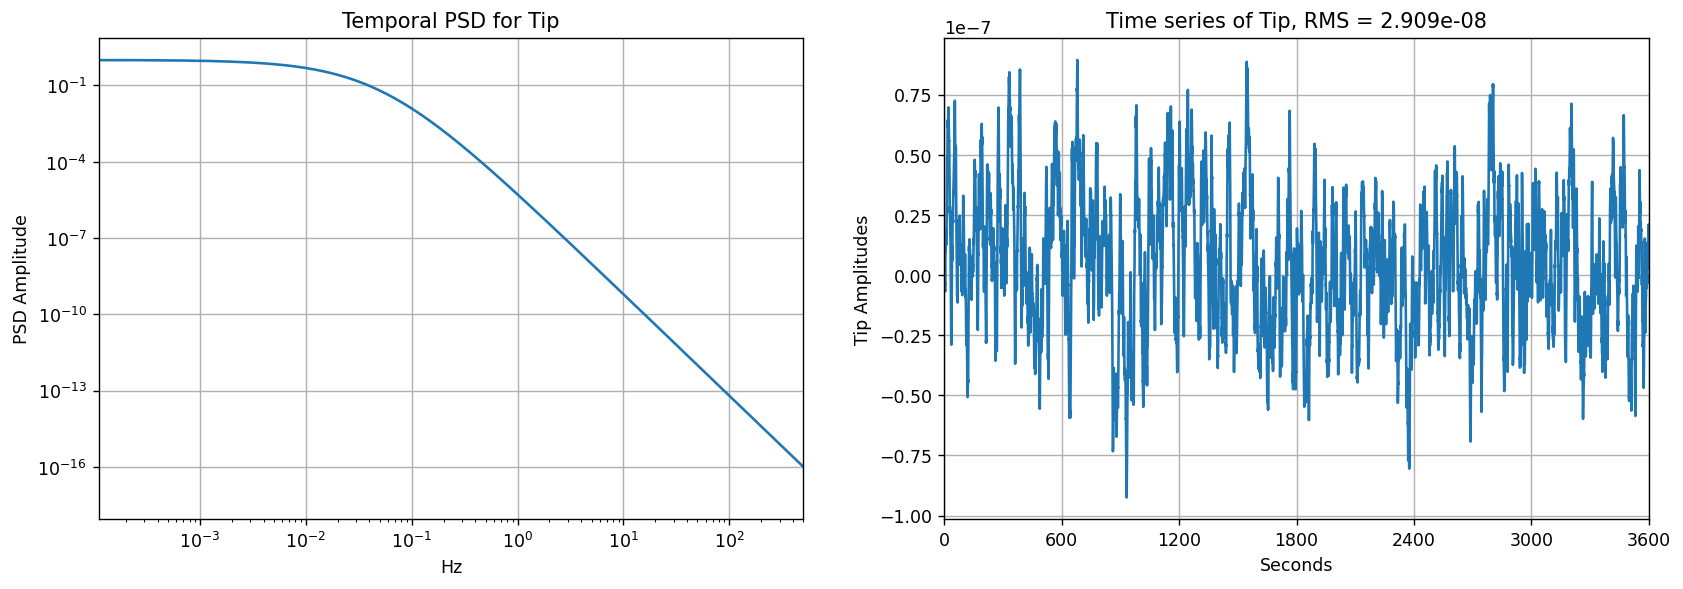

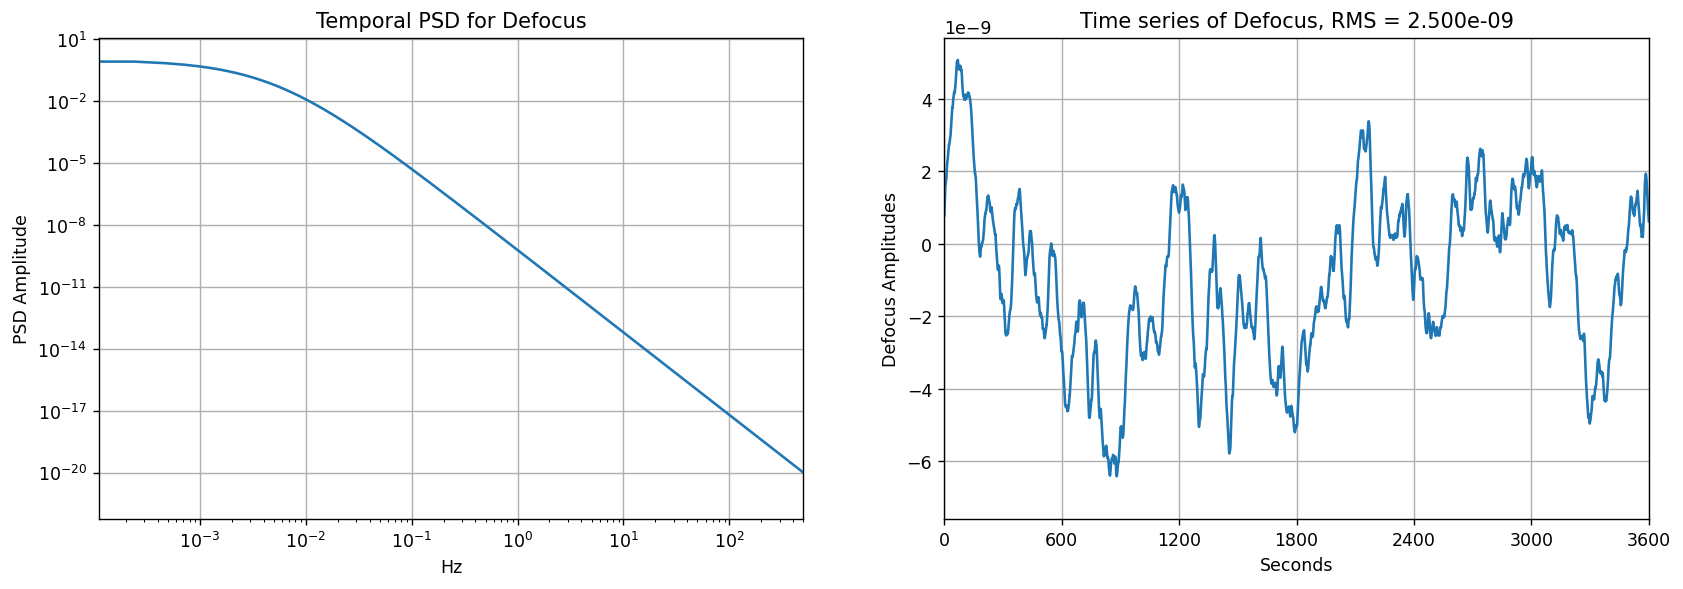

In [13]:
reload(psds)
i = 0
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 500],
    coeff_xlims=[0, 3600],
    coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 2
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 500],
    coeff_xlims=[0, 3600],
    coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)


In [8]:
wfe_modes.shape, wfe_time_series.shape

((10, 34, 34), (10, 7200000))

# Inject WFE with a while loop running at a specific frequency.

In [15]:
reload(llowfsc)

# telem.toggle(1, wfe_channel, client0)

llowfsc.inject_wfe(
    ensure_np_array(wfe_time_series),
    ensure_np_array(wfe_modes),
    wfe_stream,
    interval,
    interval_offset=0.0,
)

# telem.toggle(0, wfe_channel, client0)

Injecting WFE ...
Stopped injecting WFE.


In [22]:
time.sleep(0.0005)